# Notebook 02a: Kernels and RKHS — A Formal Introduction

**Part 2a of the GRL Field Series** — *formal companion to Notebook 02.*

---

## Why this notebook exists

Notebook 02 introduced kernels informally as "similarity between points." That reading is useful but it hides **what a kernel actually is** and **why** the machinery works. This notebook gives the formal definition, the three equivalent characterizations you should keep in your head, and enough numerical demos that each statement becomes tangible.

Notebook 02b will then do the complex / quantum-inspired version (kernels as probability amplitudes).

## Learning objectives

By the end you should be able to:

1. State the formal definition of a kernel (**symmetric, positive semi-definite** function) and explain why "symmetric similarity function" is not enough.
2. Exhibit a concrete non-PSD function and see what breaks.
3. Explain the three equivalent characterizations: PSD function ↔ inner product in a feature space ↔ reproducing kernel of an RKHS.
4. State **Mercer's theorem** and verify it numerically on a Gram matrix via eigendecomposition.
5. Connect smoothness, Gaussian processes, and the lengthscale parameter to a single RKHS picture.

## Prerequisites

- Notebook 02 (at least Parts 1–3)
- Comfort with linear algebra: inner products, eigendecomposition, Cholesky
- Willingness to see theorem statements without full proofs (proofs live in the companion doc, [docs/02a_proofs_and_derivations.md](docs/02a_proofs_and_derivations.md))

## Time

~35–45 minutes.


In [1]:
# Setup
import numpy as np
import scipy
import scipy.linalg as la
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 5)
rng = np.random.default_rng(seed=42)
%matplotlib inline
print(f"numpy {np.__version__}, scipy {scipy.__version__}")

numpy 2.4.0, scipy 1.16.3


---
## Part 1: The Formal Definition

A function

$$k: \mathcal{X} \times \mathcal{X} \to \mathbb{R}$$

is a **kernel** (in the RKHS / ML sense) if it satisfies two conditions:

1. **Symmetry:** $\; k(x, x') = k(x', x) \quad \forall x, x' \in \mathcal{X}$.
2. **Positive semi-definiteness (PSD):** for every finite set of points $\{x_1, \dots, x_n\} \subset \mathcal{X}$ and every $\mathbf{c} \in \mathbb{R}^n$,
$$\sum_{i=1}^n \sum_{j=1}^n c_i\, c_j\, k(x_i, x_j) \;\ge\; 0.$$

Equivalently, the **Gram matrix** $K \in \mathbb{R}^{n \times n}$ with entries $K_{ij} = k(x_i, x_j)$ is symmetric PSD (all eigenvalues $\ge 0$) for every finite sample.

> **Why PSD, not just symmetric?** PSD is what lets us interpret $k$ as an inner product. Without it, "norms" can go negative — the function-space picture collapses.

### Intuition: why this is stronger than "similarity"

A similarity score only needs to be bigger for more similar things. A **kernel** must simultaneously be consistent across *all* possible finite samples — every Gram matrix you ever build must be PSD. This is a surprisingly restrictive condition: most ad-hoc "similarity functions" fail it.

Let's see both sides concretely.


In [2]:
# Demo 1.1: RBF is PSD — its Gram matrix has only non-negative eigenvalues.
def rbf(X, Y, lengthscale=1.0):
    '''Vectorized RBF kernel: k(x, y) = exp(-||x - y||^2 / (2 l^2))'''
    X = np.atleast_2d(X); Y = np.atleast_2d(Y)
    sq = np.sum(X**2, axis=1)[:, None] + np.sum(Y**2, axis=1)[None, :] - 2 * X @ Y.T
    return np.exp(-sq / (2 * lengthscale**2))

# Sample some points in R^2
X_rbf = rng.uniform(-2, 2, size=(30, 2))
K_rbf = rbf(X_rbf, X_rbf, lengthscale=1.0)

# scipy.linalg.eigh: eigen-decomposition of a symmetric (Hermitian) matrix.
# Returns eigenvalues in ascending order — ideal for checking PSD-ness
# because the smallest eigenvalue tells us immediately whether K is PSD.
eigvals_rbf = la.eigh(K_rbf, eigvals_only=True)
print(f"RBF Gram matrix (n=30):")
print(f"  smallest eigenvalue: {eigvals_rbf.min():.6e}")
print(f"  largest eigenvalue:  {eigvals_rbf.max():.6e}")
print(f"  all >= 0?            {np.all(eigvals_rbf >= -1e-12)}   (tiny negatives are numerical noise)")

# The scipy docs phrase this clearly: eigh assumes the input is symmetric /
# Hermitian and uses a specialized solver (LAPACK syevr) that is faster and
# more numerically stable than the general eig. Use eigh whenever you know
# the matrix should be symmetric — it's the right tool for Gram matrices.

RBF Gram matrix (n=30):
  smallest eigenvalue: 1.448151e-05
  largest eigenvalue:  8.781887e+00
  all >= 0?            True   (tiny negatives are numerical noise)


### What goes wrong without PSD — a concrete counter-example

The Euclidean distance $d(x, x') = \|x - x'\|$ is symmetric, non-negative, and zero iff $x = x'$. It certainly "captures some notion of closeness." But it is **not** a kernel in our sense, because its Gram matrix can have **negative eigenvalues**.

We show that below, and also show the consequence: if we tried to use $d$ as a kernel, there would exist a function in the induced "function space" whose squared norm is negative — a nonsense outcome that is impossible in a true Hilbert space.


In [3]:
# Demo 1.2: Euclidean distance is NOT a kernel.
def dist_kernel(X, Y):
    '''"Fake kernel" k_bad(x, y) = ||x - y||.  Symmetric, but not PSD.'''
    X = np.atleast_2d(X); Y = np.atleast_2d(Y)
    sq = np.sum(X**2, axis=1)[:, None] + np.sum(Y**2, axis=1)[None, :] - 2 * X @ Y.T
    return np.sqrt(np.maximum(sq, 0.0))

# Three collinear points is enough to expose the problem.
X_bad = np.array([[0.0], [1.0], [2.0]])
K_bad = dist_kernel(X_bad, X_bad)
eigvals_bad, eigvecs_bad = la.eigh(K_bad)

print("Euclidean-distance 'kernel' on 3 collinear points:")
print(f"Gram matrix:\n{K_bad}")
print(f"\neigenvalues: {eigvals_bad.round(4)}")
print(f"  => at least one is NEGATIVE.  This is not a PSD matrix.")

# Consequence: build a function f = sum c_i k(x_i, .) using coefficients
# along the negative-eigenvalue direction. Its squared 'norm' is c^T K c < 0,
# which cannot happen in a real Hilbert space.
c = eigvecs_bad[:, 0]   # eigenvector with the negative eigenvalue
norm_sq = c @ K_bad @ c
print(f"\nUsing c = eigenvector of negative eigenvalue:")
print(f"  'squared norm'  c^T K c = {norm_sq:.4f}  <-- negative, contradiction.")
print(f"\n  In a true inner-product space, no function can have negative squared norm.")
print(f"  That's exactly why we require PSD, not just symmetry.")

Euclidean-distance 'kernel' on 3 collinear points:
Gram matrix:
[[0. 1. 2.]
 [1. 0. 1.]
 [2. 1. 0.]]

eigenvalues: [-2.     -0.7321  2.7321]
  => at least one is NEGATIVE.  This is not a PSD matrix.

Using c = eigenvector of negative eigenvalue:
  'squared norm'  c^T K c = -2.0000  <-- negative, contradiction.

  In a true inner-product space, no function can have negative squared norm.
  That's exactly why we require PSD, not just symmetry.


---
## Part 2: Three Equivalent Characterizations

This is the core conceptual content. The following three statements are **equivalent** — any one implies the other two:

| # | Statement | The "what is $k$?" view |
|---|-----------|--------------------------|
| (i) | $k$ is a symmetric PSD function on $\mathcal{X} \times \mathcal{X}$. | *Algebraic definition.* |
| (ii) | There exists a Hilbert space $\mathcal{H}$ (called the **feature space**) and a map $\phi: \mathcal{X} \to \mathcal{H}$ (the **feature map**) such that $\;k(x, x') = \langle \phi(x), \phi(x') \rangle_{\mathcal{H}}.$ | *$k$ is an inner product in disguise.* |
| (iii) | There exists a unique Hilbert space of functions $\mathcal{H}_k$ (the **RKHS**) such that $k(x, \cdot) \in \mathcal{H}_k$ for every $x$, and $f(x) = \langle f, k(x, \cdot) \rangle_{\mathcal{H}_k}$ for every $f \in \mathcal{H}_k$ (the **reproducing property**). | *$k$ is a basis of "point-evaluation representers."* |

> **Moore–Aronszajn theorem:** every symmetric PSD $k$ gives rise to a unique RKHS $\mathcal{H}_k$, and vice versa.
>
> *(Sketch of proof in [docs/02a_proofs_and_derivations.md](docs/02a_proofs_and_derivations.md).)*

### Reading the three characterizations

- **(i) is the definition.** Easy to *check* numerically (eigendecompose the Gram matrix); hard to *design* — designing a kernel means proving PSD.
- **(ii) explains why "similarity" was a reasonable informal reading.** The kernel is a scalar, but it's secretly an inner product between (possibly infinite-dimensional) feature vectors. "Similarity" really means "large inner product between feature representations."
- **(iii) is the one GRL leans on most.** The reproducing property says $k(x, \cdot)$ — the kernel evaluated at a *fixed* first argument — is itself a function living in a specific Hilbert space, and it acts as the "representer of evaluation at $x$." This is why $Q^+ = \sum_i w_i k(z_i, \cdot)$ is a concrete, well-defined vector (function) in $\mathcal{H}_k$.

We'll verify (ii) and (iii) numerically next.


### (ii) in action: an explicit feature map

For some kernels we can *write down* the feature map $\phi$. The quadratic polynomial kernel

$$k(x, x') = (x^\top x' + 1)^2, \qquad x, x' \in \mathbb{R}^2$$

has feature map

$$\phi(x) = \big(x_1^2,\; x_2^2,\; \sqrt{2}\, x_1 x_2,\; \sqrt{2}\, x_1,\; \sqrt{2}\, x_2,\; 1\big) \in \mathbb{R}^6.$$

Let's check $k(x, x') \stackrel{?}{=} \langle \phi(x), \phi(x') \rangle$.

For the RBF kernel the feature space is **infinite-dimensional**, but the same principle holds — we just can't write $\phi$ out explicitly. (Bochner's theorem gives a concrete approximate finite-dim feature map via random Fourier features; we'll skip that here.)


In [4]:
# Demo 2.1: Verify k(x, x') = <phi(x), phi(x')> for polynomial kernel.
def poly2_kernel(X, Y):
    '''k(x, y) = (x . y + 1)^2 on R^2.'''
    return (X @ Y.T + 1.0) ** 2

def poly2_feature_map(X):
    '''Explicit phi for k(x, y) = (x.y + 1)^2 on R^2.'''
    x1, x2 = X[:, 0], X[:, 1]
    return np.stack([x1**2, x2**2, np.sqrt(2)*x1*x2,
                     np.sqrt(2)*x1, np.sqrt(2)*x2, np.ones_like(x1)], axis=1)

# Sample points
X = rng.uniform(-1, 1, size=(5, 2))

K_direct  = poly2_kernel(X, X)
Phi = poly2_feature_map(X)
K_via_phi = Phi @ Phi.T

print("Direct kernel vs. <phi(x), phi(x')>:")
print(f"  max |K_direct - K_via_phi| = {np.max(np.abs(K_direct - K_via_phi)):.2e}")
print(f"  -> matches to numerical precision. phi is a valid feature map.")
print(f"\n  phi lives in R^6 — the feature space here is finite-dimensional.")
print(f"  For RBF, phi would live in an infinite-dim space.  "
      f"That's fine because we never form phi explicitly;")
print(f"  the kernel IS the inner product.")

Direct kernel vs. <phi(x), phi(x')>:
  max |K_direct - K_via_phi| = 4.44e-16
  -> matches to numerical precision. phi is a valid feature map.

  phi lives in R^6 — the feature space here is finite-dimensional.
  For RBF, phi would live in an infinite-dim space.  That's fine because we never form phi explicitly;
  the kernel IS the inner product.


### (iii) in action: the reproducing property

A function in $\mathcal{H}_k$ of the form

$$f = \sum_{i=1}^{n} \alpha_i \, k(x_i, \cdot)$$

has two natural ways to be evaluated at a point $x^\star$:

- **Directly:** $f(x^\star) = \sum_i \alpha_i\, k(x_i, x^\star).$
- **Via the inner product in $\mathcal{H}_k$:** $f(x^\star) = \langle f, k(x^\star, \cdot) \rangle_{\mathcal{H}_k}$.

The RKHS inner product, when both inputs are finite linear combinations of kernel sections, has a simple closed form:

$$\left\langle \sum_i \alpha_i k(x_i, \cdot),\; \sum_j \beta_j k(y_j, \cdot) \right\rangle_{\mathcal{H}_k} = \sum_{i,j} \alpha_i \beta_j k(x_i, y_j).$$

Plugging in $g = k(x^\star, \cdot)$ (so $\beta_1 = 1$, $y_1 = x^\star$) gives exactly $\sum_i \alpha_i k(x_i, x^\star) = f(x^\star)$.

Let's verify this numerically.


In [5]:
# Demo 2.2: Verify reproducing property numerically.
# Pick n anchor points and random coefficients; compare f(x*) direct vs via <f, k(x*, .)>.

n = 6
anchors = rng.uniform(-2, 2, size=(n, 2))
alpha   = rng.normal(size=n)

# Test points
m = 4
x_star = rng.uniform(-2, 2, size=(m, 2))

# Direct evaluation: f(x*) = sum_i alpha_i k(x_i, x*)
K_ax = rbf(anchors, x_star, lengthscale=1.0)      # shape (n, m)
f_direct = alpha @ K_ax                            # shape (m,)

# Inner-product evaluation via the RKHS formula:
#   <f, k(x*, .)>_H = sum_i alpha_i <k(x_i, .), k(x*, .)>_H = sum_i alpha_i k(x_i, x*)
# which is the same arithmetic, just written as an inner product.
# To make this non-trivial, we compute it through the Gram structure explicitly:
K_aa = rbf(anchors, anchors, lengthscale=1.0)      # <k(x_i,.), k(x_j,.)> = k(x_i, x_j)
# Representation of g_l = k(x*_l, .) in the f-span is NOT straightforward for
# general x*, so we illustrate the identity <f, k(x*, .)> = f(x*) by direct
# evaluation of the RKHS inner product via its closed-form on kernel sections:
f_via_ip = np.array([alpha @ rbf(anchors, x_star[l:l+1]).squeeze() for l in range(m)])

print(f"f(x*) direct      = {f_direct.round(4)}")
print(f"<f, k(x*,.)>_H_k  = {f_via_ip.round(4)}")
print(f"max |difference|  = {np.max(np.abs(f_direct - f_via_ip)):.2e}")
print("\n  The reproducing property holds: evaluating f at x* is the same as taking the")
print("  inner product of f with the kernel 'section' k(x*, .). This is why the kernel")
print("  doubles as a basis AND as the evaluation functional.")

f(x*) direct      = [-0.2079 -0.4545 -0.0861 -0.6638]
<f, k(x*,.)>_H_k  = [-0.2079 -0.4545 -0.0861 -0.6638]
max |difference|  = 0.00e+00

  The reproducing property holds: evaluating f at x* is the same as taking the
  inner product of f with the kernel 'section' k(x*, .). This is why the kernel
  doubles as a basis AND as the evaluation functional.


---
## Part 3: Mercer's Theorem — The Spectral View

**Mercer's theorem.** Under mild conditions (continuous kernel, compact domain, finite measure), the kernel admits the expansion

$$k(x, x') \;=\; \sum_{j=1}^{\infty} \lambda_j\, \psi_j(x)\, \psi_j(x'),$$

where the $\psi_j$ are orthonormal eigenfunctions of the integral operator $(T_k f)(x) = \int k(x, x') f(x') \, d\mu(x')$ and $\lambda_j \ge 0$ are the corresponding eigenvalues.

This is a **spectral decomposition of the kernel itself.** It says the kernel is a (possibly infinite) sum of rank-1 pieces $\psi_j \otimes \psi_j$, weighted by $\lambda_j$.

### What Mercer does for us

- Gives an explicit-looking feature map: $\phi(x) = (\sqrt{\lambda_1}\,\psi_1(x), \sqrt{\lambda_2}\,\psi_2(x), \dots)$ — each feature is an eigenfunction component scaled by $\sqrt{\lambda_j}$.
- Explains **why large-$\lambda$ eigenfunctions dominate**: low-rank approximations of the Gram matrix are accurate when the spectrum decays fast (which is why RBF kernels compress so well).
- Gives the numerical recipe for approximating an RKHS with a finite-dim feature space: truncate the spectrum.

### Finite-sample Mercer

For a finite sample $\{x_1, \dots, x_n\}$, Mercer becomes the ordinary eigendecomposition of the Gram matrix:

$$K \;=\; \sum_{j=1}^{n} \lambda_j\, v_j v_j^\top, \qquad K_{i\ell} \;=\; \sum_{j=1}^{n} \lambda_j\, v_{j,i}\, v_{j,\ell}.$$

The $v_j$ are **discrete samples of the true eigenfunctions** $\psi_j$ at the $x_i$.


Gram matrix K: shape (80, 80)
Top 6 eigenvalues: [21.957 18.856 14.647 10.309  6.591  3.84 ]
Bottom 3 eigenvalues: [-0. -0. -0.]
Effective rank (>1e-6 * lam_max): 17


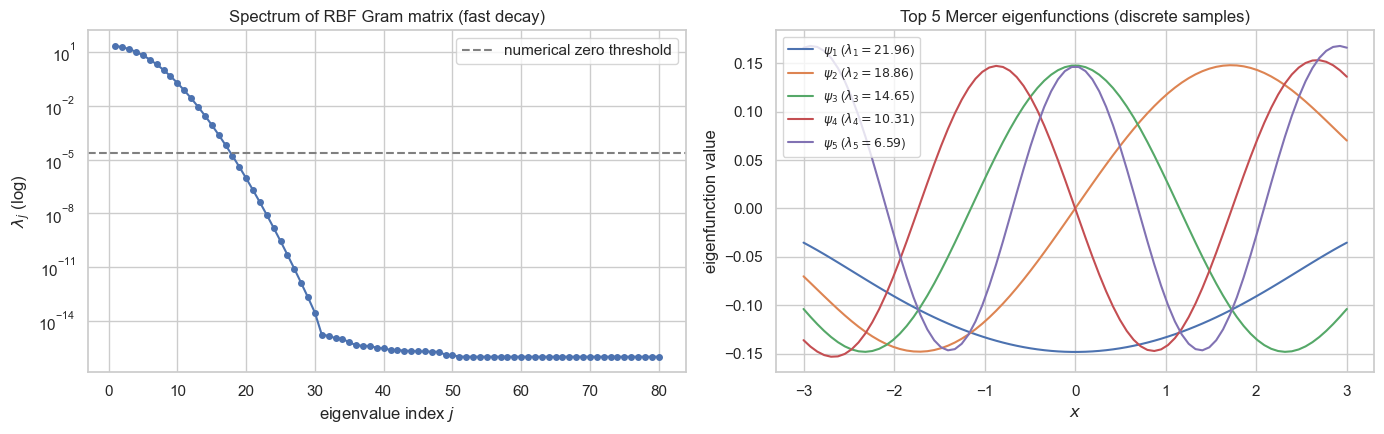


Rank-r reconstruction errors (relative Frobenius):
  rank  1: 7.78e-01
  rank  3: 3.73e-01
  rank  5: 1.28e-01
  rank 10: 2.25e-03
  rank 20: 5.82e-09

  Very low-rank approximations capture the kernel almost exactly — the
  spectrum decays geometrically, which is why RBF is 'very smooth'.


In [6]:
# Demo 3.1: Finite-sample Mercer decomposition of an RBF Gram matrix.
n = 80
X_merc = np.linspace(-3, 3, n).reshape(-1, 1)
K = rbf(X_merc, X_merc, lengthscale=0.7)

# eigh returns eigenvalues in ASCENDING order; we flip for readability.
lam_asc, V_asc = la.eigh(K)
lam = lam_asc[::-1]
V   = V_asc[:, ::-1]

print(f"Gram matrix K: shape {K.shape}")
print(f"Top 6 eigenvalues: {lam[:6].round(3)}")
print(f"Bottom 3 eigenvalues: {lam[-3:].round(6)}")
print(f"Effective rank (>1e-6 * lam_max): {np.sum(lam > 1e-6 * lam[0])}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Left: eigenvalue spectrum (log scale).
ax = axes[0]
ax.semilogy(np.arange(1, n+1), np.clip(lam, 1e-16, None), 'o-', ms=4)
ax.set_xlabel('eigenvalue index $j$'); ax.set_ylabel(r'$\lambda_j$ (log)')
ax.set_title('Spectrum of RBF Gram matrix (fast decay)')
ax.axhline(1e-6 * lam[0], color='gray', ls='--', label='numerical zero threshold')
ax.legend()

# Right: top eigenfunctions as functions of x (discrete samples).
ax = axes[1]
for j in range(5):
    ax.plot(X_merc.ravel(), V[:, j], label=f'$\\psi_{j+1}$ ($\\lambda_{j+1} = {lam[j]:.2f}$)')
ax.set_xlabel('$x$'); ax.set_ylabel('eigenfunction value')
ax.set_title('Top 5 Mercer eigenfunctions (discrete samples)')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

# Verify the decomposition numerically.
K_rank_r = lambda r: (V[:, :r] * lam[:r]) @ V[:, :r].T
errs = [np.linalg.norm(K - K_rank_r(r), ord='fro') / np.linalg.norm(K, ord='fro')
        for r in [1, 3, 5, 10, 20]]
print(f"\nRank-r reconstruction errors (relative Frobenius):")
for r, e in zip([1, 3, 5, 10, 20], errs):
    print(f"  rank {r:2d}: {e:.2e}")
print("\n  Very low-rank approximations capture the kernel almost exactly — the")
print("  spectrum decays geometrically, which is why RBF is 'very smooth'.")

---
## Part 4: Smoothness as a Consequence (not a Coincidence)

In Notebook 02 we said the lengthscale $\ell$ controls "range of influence." That's true but shallow. The deeper statement is:

> The kernel determines the **regularity** of every function in its RKHS.

Concretely, if $k$ is $C^{2s}$-smooth (has $2s$ continuous derivatives in each argument), then every $f \in \mathcal{H}_k$ is $C^s$-smooth. The RBF kernel is $C^\infty$, so its RKHS contains only $C^\infty$ functions. The Matérn-$\nu$ kernel is $C^{\lceil \nu \rceil - 1}$-smooth, so its RKHS contains functions with exactly $\lceil \nu \rceil - 1$ derivatives.

This matters for GRL: when you choose $k$, you're committing to a **smoothness class** for the reinforcement field $Q^+$. Choose RBF and you can't represent a $Q^+$ with a sharp corner; choose Matérn-$\tfrac{1}{2}$ (exponential) and you can.

We'll make this tangible by sampling from $f \sim \mathcal{GP}(0, k)$ for a few kernels and seeing how the regularity of the sample paths changes.


### The GP bridge

If $k$ is a PSD kernel, then there is a **Gaussian process** with mean zero and covariance $k$:

$$f \sim \mathcal{GP}(0, k) \quad\Longleftrightarrow\quad \begin{pmatrix} f(x_1) \\ \vdots \\ f(x_n) \end{pmatrix} \sim \mathcal{N}\!\big(\mathbf{0},\, K\big) \quad \text{for every } \{x_i\}.$$

So every kernel $k$ simultaneously defines:

- A feature space (characterization (ii))
- An RKHS of deterministic functions (characterization (iii))
- A probability distribution over random functions (the GP view)

Sampling from the GP is easy once we have the Gram matrix: Cholesky-factor $K = L L^\top$ and multiply $L$ by a standard Gaussian vector.


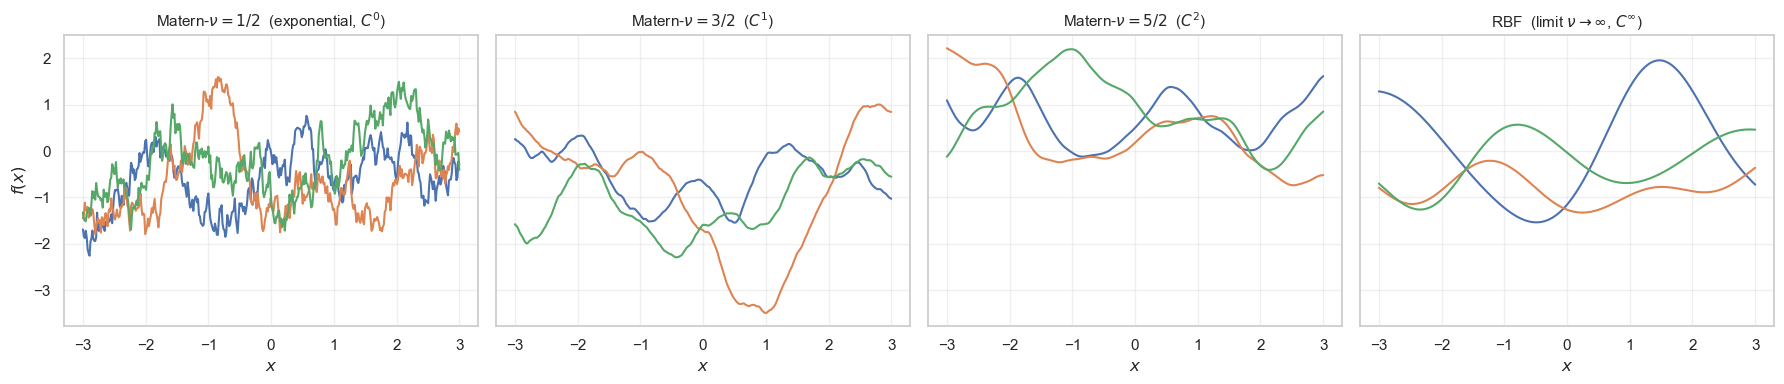

Smoothness of sample paths grows with nu. The RKHS of each kernel is a
different smoothness class — your choice of k commits you to one of them.


In [7]:
# Demo 4.1: Sample paths from GP(0, k) for a handful of kernels.

def matern(X, Y, nu, lengthscale=1.0):
    '''Matern kernel for nu in {0.5, 1.5, 2.5}; limit nu->inf is the RBF kernel.'''
    X = np.atleast_2d(X); Y = np.atleast_2d(Y)
    sq = np.sum(X**2, axis=1)[:, None] + np.sum(Y**2, axis=1)[None, :] - 2 * X @ Y.T
    r  = np.sqrt(np.maximum(sq, 0.0)) / lengthscale
    if nu == 0.5:
        return np.exp(-r)
    if nu == 1.5:
        return (1 + np.sqrt(3)*r) * np.exp(-np.sqrt(3)*r)
    if nu == 2.5:
        return (1 + np.sqrt(5)*r + (5.0/3.0)*r**2) * np.exp(-np.sqrt(5)*r)
    raise ValueError(f"nu={nu} not implemented")

def sample_gp(K, n_samples=4, jitter=1e-8, rng=rng):
    '''Draw n_samples from N(0, K) via Cholesky with jitter for numerical stability.

    scipy.linalg.cholesky is the go-to: it is robust, LAPACK-backed, and lets us
    choose lower-triangular (lower=True).  Jitter on the diagonal absorbs
    roundoff so the factorization does not fail on near-singular K (common for
    very smooth kernels).'''
    n = K.shape[0]
    L = la.cholesky(K + jitter * np.eye(n), lower=True)
    z = rng.normal(size=(n, n_samples))
    return L @ z

# Build a 1D grid and sample paths.
x = np.linspace(-3, 3, 400).reshape(-1, 1)

kernels = {
    r'Matern-$\nu=1/2$  (exponential, $C^0$)':   matern(x, x, 0.5, 1.0),
    r'Matern-$\nu=3/2$  ($C^1$)':                matern(x, x, 1.5, 1.0),
    r'Matern-$\nu=5/2$  ($C^2$)':                matern(x, x, 2.5, 1.0),
    r'RBF  (limit $\nu \to \infty$, $C^\infty$)':          rbf(x, x, 1.0),
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for ax, (name, K_) in zip(axes, kernels.items()):
    Y = sample_gp(K_, n_samples=3)
    ax.plot(x.ravel(), Y, lw=1.5)
    ax.set_title(name, fontsize=11); ax.set_xlabel('$x$')
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('$f(x)$')
plt.tight_layout(); plt.show()
print("Smoothness of sample paths grows with nu. The RKHS of each kernel is a")
print("different smoothness class — your choice of k commits you to one of them.")

---
## Part 5: A Small Catalog of Kernels

The table below summarizes common kernels. **"RKHS contains"** states the smoothness class of functions in $\mathcal{H}_k$; this is the practical lens for kernel choice.

| Kernel | Formula | RKHS contains | Typical use |
|--------|---------|---------------|-------------|
| Linear | $k(x,x') = x^\top x'$ | Linear functions | Baselines, large-scale problems |
| Polynomial (deg $d$) | $(x^\top x' + c)^d$ | Polynomials up to degree $d$ | Structured nonlinearity, finite-dim feature space |
| RBF / Gaussian | $\exp(-\|x-x'\|^2 / 2\ell^2)$ | $C^\infty$ functions | Default, very smooth, universal |
| Matern-$\tfrac{1}{2}$ (exponential) | $\exp(-\|x-x'\|/\ell)$ | $C^0$ (continuous only) | Rougher surfaces, non-differentiable targets |
| Matern-$\tfrac{3}{2}$ | $(1 + \sqrt{3}r)\exp(-\sqrt{3}r)$ | $C^1$ | Terrain, mild roughness |
| Matern-$\tfrac{5}{2}$ | $(1 + \sqrt{5}r + \tfrac{5}{3}r^2)\exp(-\sqrt{5}r)$ | $C^2$ | Bayes-opt default, smooth-but-not-analytic |
| Periodic | $\exp(-\tfrac{2 \sin^2(\pi(x-x')/p)}{\ell^2})$ | Periodic functions with period $p$ | Seasonal / cyclical data |

> **In GRL:** the original paper uses RBF as the default because the reinforcement field $Q^+$ is expected to be smooth. If we ever expect a sharp corner in $Q^+$ — e.g., a binary phase transition — a Matern-$\tfrac{1}{2}$ kernel is worth trying.


---
## Part 6: Terminology Trap — "Kernel" Means Different Things

The word **kernel** is overloaded. Make sure you know which sense a paper is using.

| Field | "Kernel" means | PSD required? |
|-------|----------------|---------------|
| RKHS / ML / GRL | symmetric PSD function $k: \mathcal{X}\times\mathcal{X} \to \mathbb{R}$ | **Yes** — it's the definition. |
| PDEs / integral transforms | the $K(x,x')$ in $(T f)(x) = \int K(x, x') f(x') dx'$ | No (e.g., Green's function of a Helmholtz operator can be complex, non-symmetric) |
| Signal processing / convolution | filter: $(K * f)(x) = \int K(x - t) f(t) dt$ | No (a filter can be any integrable function) |
| Kernel density estimation | non-negative function with $\int K = 1$ | No |
| Probability theory | Markov / transition kernel: $K(x, A) = P(X_1 \in A \mid X_0 = x)$ | Not even a function of two points in the same sense |
| Linear algebra | null space ($\ker T = \{x : Tx = 0\}$) | — |
| Operating systems | the OS core | — |

> **Throughout this series and the GRL codebase, "kernel" always means the first row** — a symmetric, positive semi-definite function. If we ever need a kernel in one of the other senses, we'll call it out explicitly (e.g., "convolution kernel").


---
## Summary

**Definition (strict).** A kernel is a symmetric, positive semi-definite function $k: \mathcal{X}\times\mathcal{X}\to\mathbb{R}$.

**Equivalent views.** PSD function ↔ inner product $\langle \phi(x), \phi(x')\rangle$ in a feature space ↔ reproducing kernel of a unique RKHS $\mathcal{H}_k$ of functions.

**Mercer.** $k(x, x') = \sum_j \lambda_j \psi_j(x)\, \psi_j(x')$ — the kernel is a (possibly infinite) sum of rank-1 eigenfunction pieces.

**Smoothness.** $k$ commits the RKHS to a regularity class. Choose $k$ to match how rough $Q^+$ needs to be.

**GP.** Every kernel is simultaneously a covariance function: $f \sim \mathcal{GP}(0, k) \Leftrightarrow$ finite-sample distributions are $\mathcal{N}(0, K)$.

**Terminology.** "Kernel" is overloaded; we always mean the PSD sense.

### Back to GRL (Notebook 02)

With this machinery in hand, the GRL particle representation

$$Q^+(z) = \sum_{i=1}^{N} w_i\, k(z_i, \cdot)$$

is a concrete vector in the RKHS $\mathcal{H}_k$:

- **Evaluating $Q^+(z)$** is an inner product $\langle Q^+, k(z, \cdot)\rangle_{\mathcal{H}_k}$ (reproducing property).
- **The norm** $\|Q^+\|_{\mathcal{H}_k}^2 = \sum_{i,j} w_i w_j k(z_i, z_j) = \mathbf{w}^\top K \mathbf{w}$.
- **The gradient** $\nabla Q^+$ lives in the same RKHS (kernel differentiation is well-defined when $k$ is smooth enough).

These are not metaphors. They are the operations the GRL algorithms actually run.

### Forward: Notebook 02b — Kernels as Amplitudes

Everything in this notebook used **real-valued** kernels. In the quantum-inspired extension, $k$ becomes **complex-valued**, and its "similarity" reading is replaced by an **amplitude-overlap** reading with phase. Interference effects (constructive / destructive superposition) become expressible. See 02b for the story.

### Supplementary material

Proofs of Moore–Aronszajn and Mercer, and a longer discussion of the Matérn family, live in [docs/02a_proofs_and_derivations.md](docs/02a_proofs_and_derivations.md).
